In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import umap.umap_ as umap

In [4]:
df = pd.read_csv("AirQualityUCI.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [5]:
df = df.drop(columns=["Unnamed: 15", "Unnamed: 16"], errors="ignore")

print("New shape:", df.shape)

New shape: (9471, 15)


In [6]:
features = [
    "CO(GT)",
    "PT08.S1(CO)",
    "NMHC(GT)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH"
]

X = df[features].copy()

print("Selected features:")
print(X.columns.tolist())

Selected features:
['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


In [7]:
X = X.replace(-200, np.nan)

print("Missing values after replacing -200:")
print(X.isnull().sum())

Missing values after replacing -200:
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64


In [8]:
X = X.fillna(X.median())

print("Total missing values:", X.isnull().sum().sum())

Total missing values: 0


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization completed!")
print("Shape of standardized data:", X_scaled.shape)

Standardization completed!
Shape of standardized data: (9471, 13)


In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed!")
print("PCA shape:", X_pca.shape)

PCA completed!
PCA shape: (9471, 2)


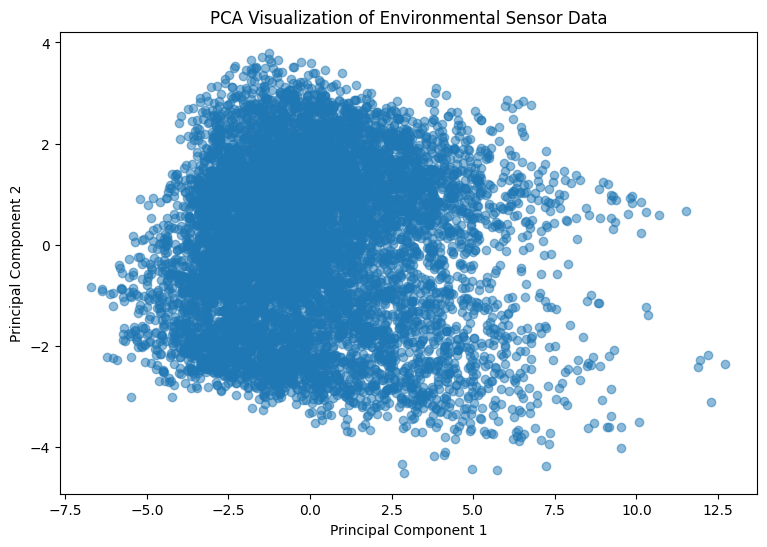

In [12]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Environmental Sensor Data")

plt.show()

In [13]:
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

print("UMAP completed!")
print("UMAP shape:", X_umap.shape)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completed!
UMAP shape: (9471, 2)


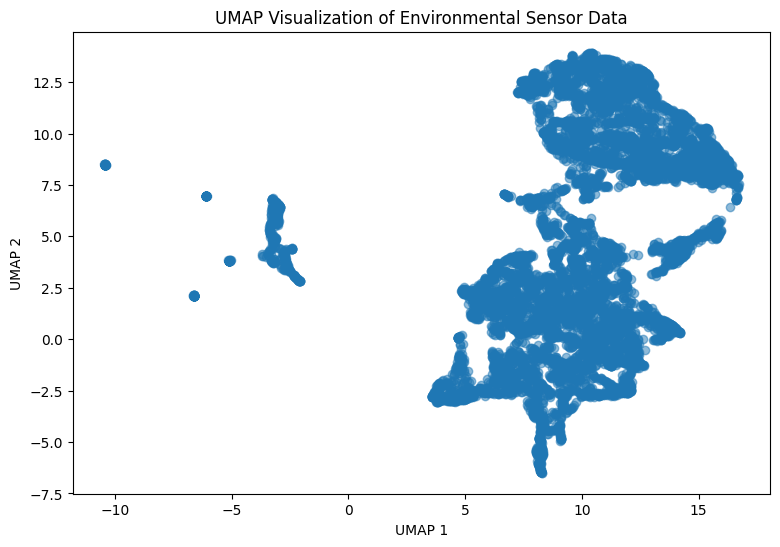

In [14]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    alpha=0.5
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Visualization of Environmental Sensor Data")

plt.show()

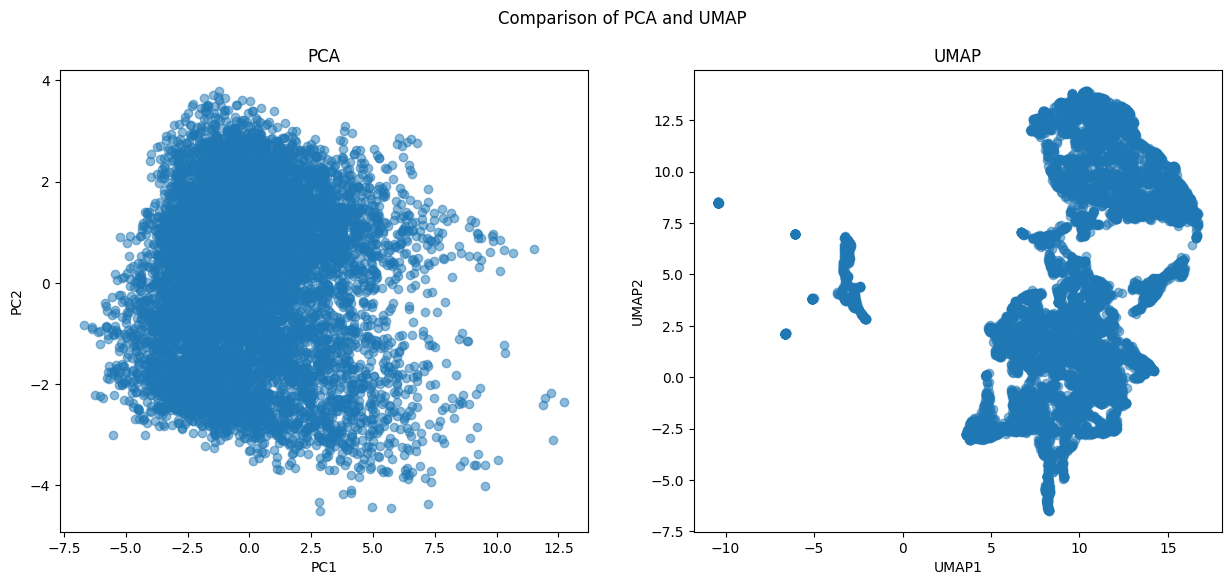

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.5
)

axes[0].set_title("PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")


axes[1].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    alpha=0.5
)

axes[1].set_title("UMAP")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

plt.suptitle("Comparison of PCA and UMAP")
plt.show()

In [16]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_umap)

print("Clusters created successfully!")
print("Number of clusters:", len(np.unique(clusters)))

Clusters created successfully!
Number of clusters: 4


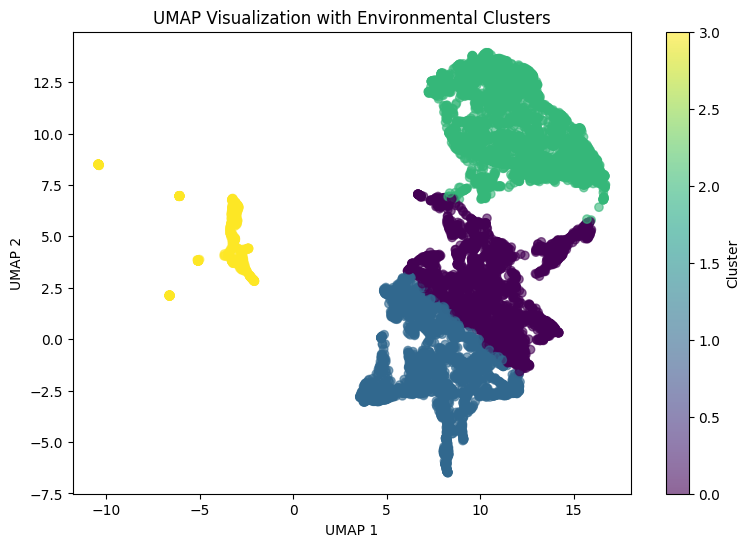

In [17]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=clusters,
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Visualization with Environmental Clusters")

plt.colorbar(scatter, label="Cluster")

plt.show()

In [18]:
analysis_df = X.copy()

analysis_df["Cluster"] = clusters

analysis_df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Cluster
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,1
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,1
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,1
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,1
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,1


In [19]:
cluster_summary = analysis_df.groupby("Cluster")[features].mean()

cluster_summary

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Cluster,,,,,,,,,,,,,
0,2.030129,1109.562522,150.000000,11.653187,1000.788924,199.998955,771.561477,103.556600,1661.613723,1048.442703,25.547614,47.976698,1.445721
1,1.924565,1084.857899,173.288360,9.469803,921.720333,129.849584,957.925548,92.310658,1573.725246,926.030612,20.251890,44.155367,0.975429
2,2.214788,1103.291150,150.000000,9.254828,901.515422,334.419717,794.970020,132.971462,1196.709138,1075.626982,10.858864,54.154944,0.716094
3,2.372784,1062.752577,152.624742,8.195464,908.771134,295.274227,806.655670,125.896907,1463.012371,963.882474,17.807216,49.552577,0.994953


<Figure size 1400x700 with 0 Axes>

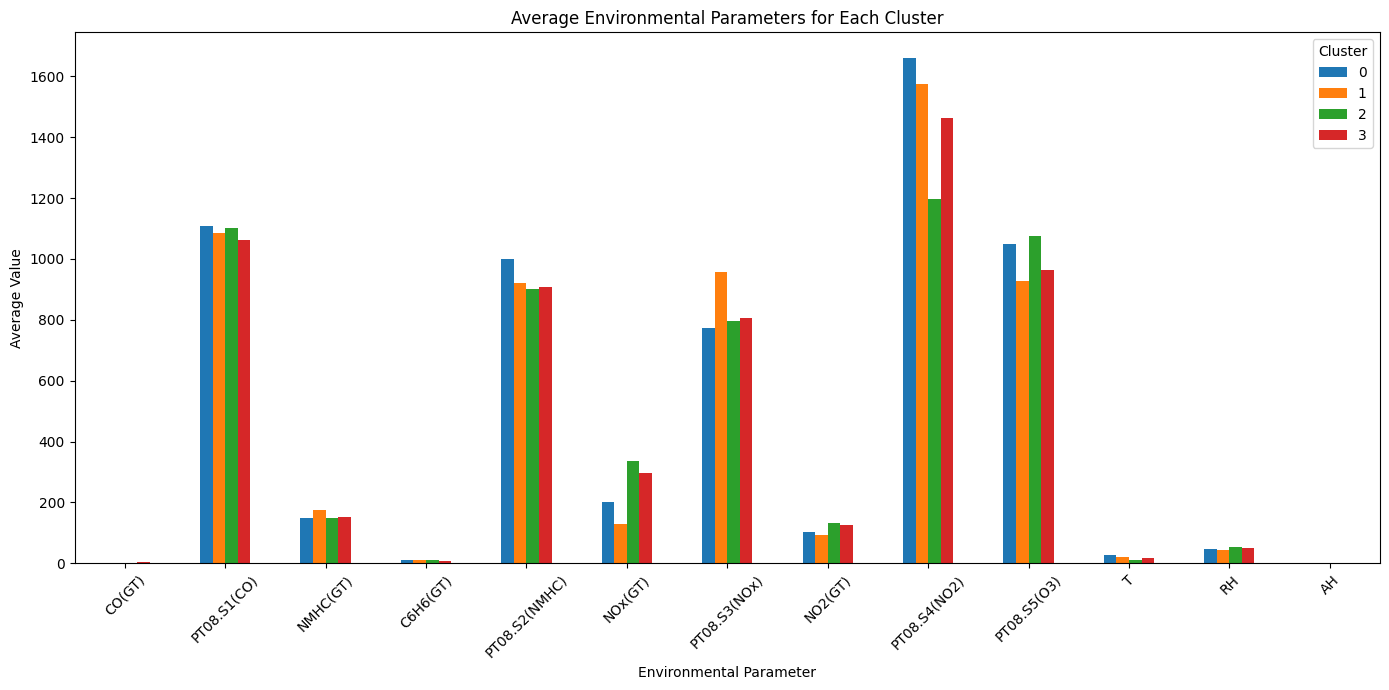

In [20]:
plt.figure(figsize=(14, 7))

cluster_summary.T.plot(kind="bar", figsize=(14, 7))

plt.title("Average Environmental Parameters for Each Cluster")
plt.xlabel("Environmental Parameter")
plt.ylabel("Average Value")
plt.xticks(rotation=45)

plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

In [21]:
for cluster in sorted(analysis_df["Cluster"].unique()):

    print("\n" + "=" * 50)
    print(f"CLUSTER {cluster}")
    print("=" * 50)

    cluster_data = analysis_df[
        analysis_df["Cluster"] == cluster
    ][features]

    print(cluster_data.mean().round(2))


CLUSTER 0
CO(GT)              2.03
PT08.S1(CO)      1109.56
NMHC(GT)          150.00
C6H6(GT)           11.65
PT08.S2(NMHC)    1000.79
NOx(GT)           200.00
PT08.S3(NOx)      771.56
NO2(GT)           103.56
PT08.S4(NO2)     1661.61
PT08.S5(O3)      1048.44
T                  25.55
RH                 47.98
AH                  1.45
dtype: float64

CLUSTER 1
CO(GT)              1.92
PT08.S1(CO)      1084.86
NMHC(GT)          173.29
C6H6(GT)            9.47
PT08.S2(NMHC)     921.72
NOx(GT)           129.85
PT08.S3(NOx)      957.93
NO2(GT)            92.31
PT08.S4(NO2)     1573.73
PT08.S5(O3)       926.03
T                  20.25
RH                 44.16
AH                  0.98
dtype: float64

CLUSTER 2
CO(GT)              2.21
PT08.S1(CO)      1103.29
NMHC(GT)          150.00
C6H6(GT)            9.25
PT08.S2(NMHC)     901.52
NOx(GT)           334.42
PT08.S3(NOx)      794.97
NO2(GT)           132.97
PT08.S4(NO2)     1196.71
PT08.S5(O3)      1075.63
T                  10.86
RH          

In [22]:
overall_mean = analysis_df[features].mean()

for cluster in sorted(analysis_df["Cluster"].unique()):

    cluster_mean = analysis_df[
        analysis_df["Cluster"] == cluster
    ][features].mean()

    difference = cluster_mean - overall_mean

    print("\n" + "=" * 50)
    print(f"CLUSTER {cluster} CHARACTERISTICS")
    print("=" * 50)

    print("\nHigher than overall average:")
    print(difference[difference > 0].sort_values(ascending=False).head(5))

    print("\nLower than overall average:")
    print(difference[difference < 0].sort_values().head(5))


CLUSTER 0 CHARACTERISTICS

Higher than overall average:
PT08.S4(NO2)     205.007768
PT08.S2(NMHC)     63.163752
PT08.S5(O3)       28.572679
PT08.S1(CO)       11.596098
T                  7.256029
dtype: float64

Lower than overall average:
PT08.S3(NOx)   -62.437362
NOx(GT)        -34.515774
NO2(GT)         -8.776099
NMHC(GT)        -6.640693
RH              -1.276042
dtype: float64

CLUSTER 1 CHARACTERISTICS

Higher than overall average:
PT08.S3(NOx)    123.926709
PT08.S4(NO2)    117.119291
NMHC(GT)         16.647667
T                 1.960305
dtype: float64

Lower than overall average:
NOx(GT)         -104.665145
PT08.S5(O3)      -93.839412
NO2(GT)          -20.022042
PT08.S2(NMHC)    -15.904839
PT08.S1(CO)      -13.108525
dtype: float64

CLUSTER 2 CHARACTERISTICS

Higher than overall average:
NOx(GT)        99.904988
PT08.S5(O3)    55.756958
NO2(GT)        20.638762
PT08.S1(CO)     5.324726
RH              4.902204
dtype: float64

Lower than overall average:
PT08.S4(NO2)    -259.896

In [23]:
print("========== PROJECT SUMMARY ==========")

print("Original data shape:", df.shape)
print("Number of features used:", len(features))

print("\nPCA:")
print("Dimensions:", X_pca.shape)
print("Explained variance:",
      round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

print("\nUMAP:")
print("Dimensions:", X_umap.shape)

print("\nClusters:")
print("Number of clusters:", len(np.unique(clusters)))

========== PROJECT SUMMARY ==========
Original data shape: (9471, 15)
Number of features used: 13

PCA:
Dimensions: (9471, 2)
Explained variance: 70.41 %

UMAP:
Dimensions: (9471, 2)

Clusters:
Number of clusters: 4
